# 01: Data Audit

- **920** recordings, **6898** cycles split as **Normal 3642 / Crackle 1864 / Wheeze 886 / Both 506**.
- Device totals: **AKGC417L 646 · LittC2SE 87 · Litt3200 60 · Meditron 127**.
- Official train/test split: 539 / 381.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/safina57/project-deep-learning.git"

def _find_root():
    cwd = Path.cwd().resolve()
    for p in (cwd, *cwd.parents):
        if (p / "pyproject.toml").exists():
            return p
    return None

ROOT = _find_root()
if ROOT is None:
    if "google.colab" in sys.modules:
        target = Path("/content/repo")
        if not target.exists():
            subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(target)], check=True)
        os.chdir(target)
        ROOT = _find_root()
    if ROOT is None:
        raise RuntimeError(
            "Project root not found. Locally: launch from inside the cloned repo. "
            "On Colab: ensure git is available and the repo URL is reachable."
        )
sys.path.insert(0, str(ROOT))
print(f"project root: {ROOT}")

if "google.colab" in sys.modules:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "transformers", "librosa", "soundfile", "python-dotenv", "kaggle"],
        check=True,
    )

project root: /content/repo


## Data bootstrap (Colab only)
Locally this cell is a no-op.

In [2]:
import urllib.request

SPLIT_URL = (
    "https://raw.githubusercontent.com/joetho786/"
    "Respiratory-Sound-Classification-in-Wearable-Devices-Enabled-by-Patient-Specific-Model-Tuning/"
    "main/ICBHI_challenge_train_test.txt"
)

if "google.colab" in sys.modules:
    from google.colab import userdata
    os.environ.setdefault("KAGGLE_USERNAME", userdata.get("KAGGLE_USERNAME"))
    os.environ.setdefault("KAGGLE_KEY", userdata.get("KAGGLE_KEY"))

    LOCAL_DATA = ROOT / "data" / "icbhi"
    ANNOT_DIR = LOCAL_DATA / "ICBHI_final_database"
    if not (ANNOT_DIR.exists() and any(ANNOT_DIR.iterdir())):
        subprocess.run([sys.executable, str(ROOT / "scripts/download_icbhi.py")], check=True)
    if not (ANNOT_DIR / "train_test.txt").exists():
        urllib.request.urlretrieve(SPLIT_URL, ANNOT_DIR / "train_test.txt")
        print("fetched train_test.txt")
    os.environ["ICBHI_ROOT"] = str(LOCAL_DATA)

fetched train_test.txt


In [3]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display

from src.data.paths import EXPECTED_WAV, EXPECTED_TXT, detect_runtime, get_icbhi_root, find_audio_dir, find_split_file
from src.data.splits import train_test
from src.data.annotations import parse_annotation, label_4class, CLASS_NAMES

print(f"runtime: {detect_runtime()}")
root      = get_icbhi_root()
audio_dir = find_audio_dir(root)
print(f"audio_dir: {audio_dir}")

runtime: colab
audio_dir: /content/repo/data/icbhi/ICBHI_final_database


## File counts

In [4]:
wavs = list(audio_dir.glob("*.wav"))
txts = list(audio_dir.glob("*.txt"))
print(f".wav files: {len(wavs)}  (expected {EXPECTED_WAV})")
print(f".txt files: {len(txts)}  (expected {EXPECTED_TXT})")
assert len(wavs) == EXPECTED_WAV
assert len(txts) == EXPECTED_TXT

.wav files: 920  (expected 920)
.txt files: 923  (expected 923)


## Splits and devices

In [5]:
train, test = train_test(root)
print(f"recordings: {len(train)} train + {len(test)} test = {len(train)+len(test)} total")

train_patients = set(r.patient_id for r in train)
test_patients  = set(r.patient_id for r in test)
overlap = sorted(train_patients & test_patients)
print(f"patients: {len(train_patients)} train, {len(test_patients)} test, {len(train_patients|test_patients)} unique")
print(f"cross-split patients (canonical ICBHI leak): {overlap}")

recordings: 539 train + 381 test = 920 total
patients: 79 train, 49 test, 126 unique
cross-split patients (canonical ICBHI leak): [156, 218]


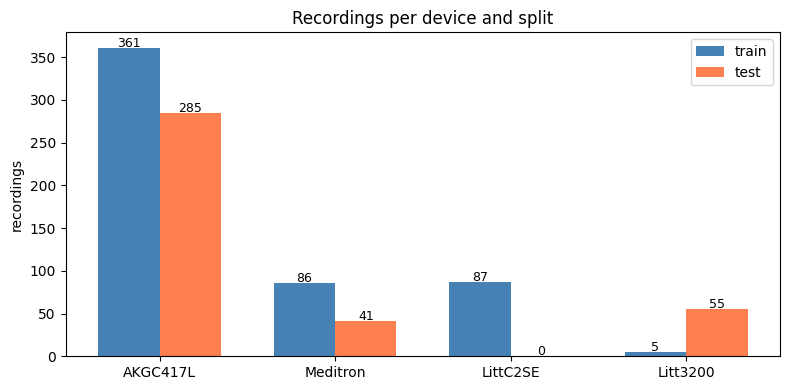

Note: LittC2SE is 100% train; Litt3200 is 91% test — per-device test metrics are unreliable for these two.


In [6]:
DEVICES = ["AKGC417L", "Meditron", "LittC2SE", "Litt3200"]
train_dev = Counter(r.device for r in train)
test_dev  = Counter(r.device for r in test)

x = np.arange(len(DEVICES))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, [train_dev[d] for d in DEVICES], w, label="train", color="steelblue")
ax.bar(x + w/2, [test_dev[d]  for d in DEVICES], w, label="test",  color="coral")
ax.set_xticks(x); ax.set_xticklabels(DEVICES)
ax.set_ylabel("recordings")
ax.set_title("Recordings per device and split")
ax.legend()
for i, d in enumerate(DEVICES):
    ax.text(i - w/2, train_dev[d] + 1, str(train_dev[d]), ha="center", fontsize=9)
    ax.text(i + w/2, test_dev[d]  + 1, str(test_dev[d]),  ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("Note: LittC2SE is 100% train; Litt3200 is 91% test — per-device test metrics are unreliable for these two.")

## Cycle-level audit

In [7]:
rows = []
for r in train + test:
    for start, end, c, w in parse_annotation(r.txt_path):
        rows.append({
            "patient_id": r.patient_id, "device": r.device,
            "split": r.split, "wav_path": str(r.wav_path),
            "start": start, "end": end,
            "duration": end - start,
            "label": label_4class(c, w),
            "class_name": CLASS_NAMES[label_4class(c, w)],
        })
cycles = pd.DataFrame(rows)
print(f"total cycles: {len(cycles)}")
print(cycles.groupby("class_name")["duration"].describe().round(2))

total cycles: 6898
             count  mean   std   min   25%   50%   75%    max
class_name                                                   
Both         506.0  3.06  1.09  0.57  2.24  2.90  3.56   8.59
Crackle     1864.0  2.78  0.95  0.37  2.14  2.63  3.45   8.74
Normal      3642.0  2.61  1.28  0.20  1.72  2.44  3.29  16.16
Wheeze       886.0  2.70  1.14  0.23  1.80  2.58  3.36   9.22


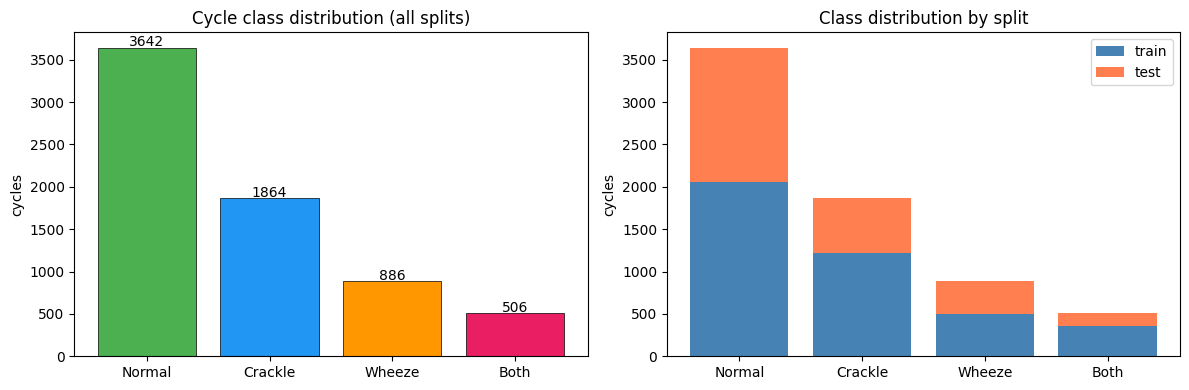

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class imbalance
counts = [int((cycles["label"] == k).sum()) for k in range(4)]
colors = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63"]
bars = axes[0].bar(CLASS_NAMES, counts, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_title("Cycle class distribution (all splits)")
axes[0].set_ylabel("cycles")
for bar, n in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(n), ha="center", fontsize=10)

# Class by split stacked
train_counts = [int((cycles[cycles.split=="train"]["label"]==k).sum()) for k in range(4)]
test_counts  = [int((cycles[cycles.split=="test" ]["label"]==k).sum()) for k in range(4)]
x = np.arange(4)
axes[1].bar(x, train_counts, label="train", color="steelblue")
axes[1].bar(x, test_counts,  bottom=train_counts, label="test", color="coral")
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set_title("Class distribution by split")
axes[1].set_ylabel("cycles")
axes[1].legend()

plt.tight_layout(); plt.show()

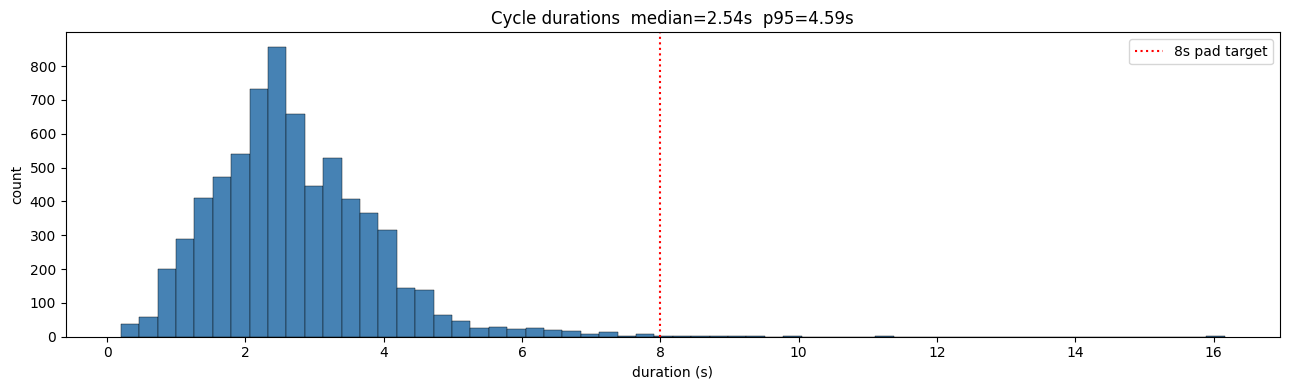

Cycles <= 8s: 99.8% — cyclic padding fills these.
Cycles  > 8s: 0.2% — truncated to 8s.


In [16]:
fig, ax = plt.subplots(figsize=(13, 4))

# Duration histogram
ax.hist(cycles["duration"], bins=60, edgecolor="black", linewidth=0.3, color="steelblue")
ax.axvline(8.0, color="red", linestyle=":", label="8s pad target")
ax.set_xlabel("duration (s)")
ax.set_ylabel("count")
ax.set_title(f"Cycle durations  median={cycles['duration'].median():.2f}s  p95={cycles['duration'].quantile(0.95):.2f}s")
ax.legend()


plt.tight_layout(); plt.show()
share = (cycles["duration"] <= 8.0).mean()
print(f"Cycles <= 8s: {share:.1%} — cyclic padding fills these.")
print(f"Cycles  > 8s: {1-share:.1%} — truncated to 8s.")

## Log-Mel spectrograms: 3 examples per class

Each panel shows one respiratory cycle loaded from disk, resampled to 16 kHz, and converted to a log-Mel spectrogram (128 bins, 25 ms window, 10 ms hop). This is what the AST model sees as input.

- **Normal**: smooth, low-energy spectrogram.
- **Crackle**: short, wide-frequency vertical bursts (~5-15 ms).
- **Wheeze**: sustained horizontal band around ~400 Hz.
- **Both**: both patterns present.

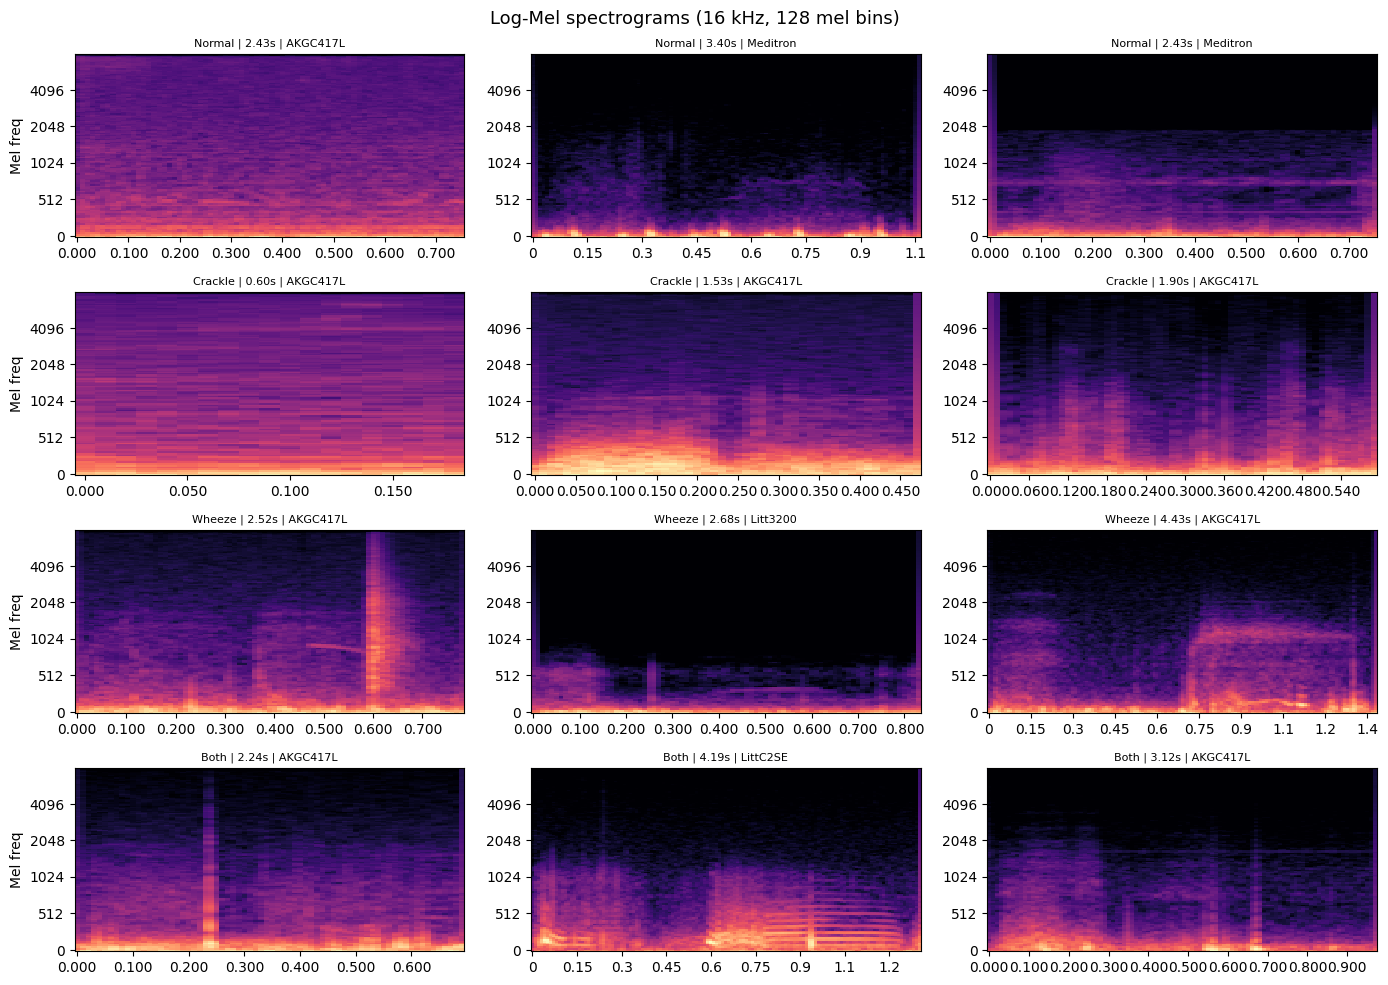

In [10]:
import random
random.seed(42)

SR = 16000
N_EXAMPLES = 3
N_MELS = 128

fig, axes = plt.subplots(4, N_EXAMPLES, figsize=(14, 10))
fig.suptitle("Log-Mel spectrograms (16 kHz, 128 mel bins)", fontsize=13)

for row, (label_idx, class_name) in enumerate(enumerate(CLASS_NAMES)):
    # Sample N_EXAMPLES cycles of this class
    candidates = cycles[cycles.label == label_idx].sample(n=N_EXAMPLES, random_state=row).itertuples()
    for col, cyc in enumerate(candidates):
        audio, _ = librosa.load(cyc.wav_path, sr=SR, mono=True)
        start_s = int(cyc.start * SR)
        end_s   = int(cyc.end   * SR)
        segment = audio[start_s:end_s]

        mel = librosa.feature.melspectrogram(y=segment, sr=SR, n_mels=N_MELS, fmax=8000)
        log_mel = librosa.power_to_db(mel, ref=np.max)

        ax = axes[row][col]
        img = librosa.display.specshow(log_mel, sr=SR, hop_length=160, x_axis="time",
                                        y_axis="mel", ax=ax, cmap="magma")
        dur = cyc.end - cyc.start
        ax.set_title(f"{class_name} | {dur:.2f}s | {cyc.device}", fontsize=8)
        ax.set_xlabel("")
        ax.set_ylabel("" if col > 0 else "Mel freq")

plt.tight_layout()
plt.show()

## Average frequency spectrum per class

Mean FFT magnitude across all cycles of each class (first 500 ms per cycle for speed). Shows the characteristic frequency bands: crackles and wheezes concentrate energy differently than normal breathing.

Normal:   0%|          | 0/60 [00:00<?, ?it/s]

Crackle:   0%|          | 0/60 [00:00<?, ?it/s]

Wheeze:   0%|          | 0/60 [00:00<?, ?it/s]

Both:   0%|          | 0/60 [00:00<?, ?it/s]

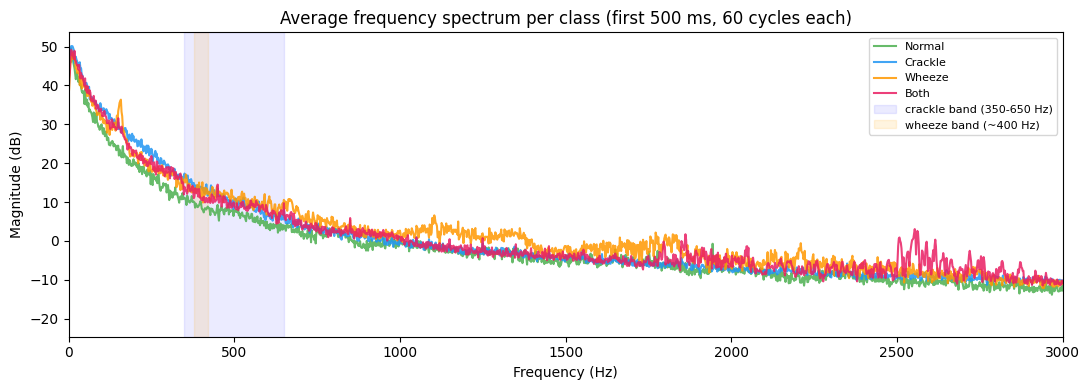

In [11]:
from tqdm.auto import tqdm

SAMPLE_PER_CLASS = 60   # load this many cycles per class for the average
FFT_SAMPLES = SR // 2   # 500 ms

spectra = {name: [] for name in CLASS_NAMES}

for label_idx, class_name in enumerate(CLASS_NAMES):
    sample = cycles[cycles.label == label_idx].sample(
        n=min(SAMPLE_PER_CLASS, int((cycles.label == label_idx).sum())),
        random_state=label_idx
    )
    for cyc in tqdm(sample.itertuples(), total=len(sample), desc=class_name, leave=False):
        audio, _ = librosa.load(cyc.wav_path, sr=SR, mono=True)
        seg = audio[int(cyc.start * SR): int(cyc.start * SR) + FFT_SAMPLES]
        if len(seg) < FFT_SAMPLES:
            seg = np.pad(seg, (0, FFT_SAMPLES - len(seg)))
        mag = np.abs(np.fft.rfft(seg))
        spectra[class_name].append(mag)

freqs = np.fft.rfftfreq(FFT_SAMPLES, d=1/SR)

fig, ax = plt.subplots(figsize=(11, 4))
for (class_name, mags), color in zip(spectra.items(), colors):
    mean_mag = np.mean(mags, axis=0)
    ax.plot(freqs, 20 * np.log10(mean_mag + 1e-10), label=class_name, color=color, alpha=0.85)

ax.axvspan(350, 650, alpha=0.08, color="blue",   label="crackle band (350-650 Hz)")
ax.axvspan(380, 420, alpha=0.12, color="orange", label="wheeze band (~400 Hz)")
ax.set_xlim(0, 3000)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title(f"Average frequency spectrum per class (first 500 ms, {SAMPLE_PER_CLASS} cycles each)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Cross-tabulations

In [12]:
print("Cycles by class and split:")
print(pd.crosstab(cycles["class_name"], cycles["split"], margins=True))
print()
print("Cycles by class and device:")
print(pd.crosstab(cycles["class_name"], cycles["device"], margins=True))

Cycles by class and split:
split       test  train   All
class_name                   
Both         143    363   506
Crackle      649   1215  1864
Normal      1579   2063  3642
Wheeze       385    501   886
All         2756   4142  6898

Cycles by class and device:
device      AKGC417L  Litt3200  LittC2SE  Meditron   All
class_name                                              
Both             381        25        44        56   506
Crackle         1543        29        77       215  1864
Normal          1922       336       347      1037  3642
Wheeze           500       112       126       148   886
All             4346       502       594      1456  6898


## Summary

- File counts match: 920 .wav, 923 .txt.
- Recording split matches brief: 539 train / 381 test, device totals 646/87/60/127.
- Cycle counts match brief: 3642/1864/886/506 = 6898.
- **LittC2SE is 100% train, Litt3200 is 91% test** per-device test metrics unreliable for both.
- Canonical 2-patient cross-split (156, 218) confirmed.
- 99.8% of cycles are under 8s cyclic padding covers virtually all cycles without truncation.
- Crackle cycles show wider frequency bursts in the spectrogram; wheeze shows sustained bands; both patterns are clearly distinct from normal in the log-Mel representation.